In [1]:
# Notebook to run the stage 1 and stage 2 estimation on cross-sectional data, encompassing the whole SP500 stocks

In [1]:
import importlib
import cross_sectional_estimation as cse
importlib.reload(cse)

<module 'cross_sectional_estimation' from '/Users/tommasodifrancesco/Desktop/Lasso_paper/Empirical/scripts/lasso_11_2025/cross_sectional_estimation.py'>

In [3]:
out = cse.main(
    out_dir="results_full",
    ar1_innovations=True,
    n_jobs=3,
    resume=True,        # default
    save_outputs=True   # default
)

Estimating per stock:   0%|          | 0/1620 [00:00<?, ?it/s]

Python(22911) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22912) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(22913) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


KeyboardInterrupt: 

In [3]:
results_df = out["results_df"]
details_per_stock = out["details_per_stock"]
summary_per_stock = out["summary_per_stock"]

In [6]:
summary_per_stock

{'20053': {'window_size': 360,
  'n_lags': 21,
  'lambda': 0.002536652371477602,
  'r2_insample_stage1': np.float64(0.19727346549605626),
  'r2_oos_stage1': np.float64(-0.07733541380600473),
  'r2_insample_stage2': np.float64(-1.0805578654071724e-11),
  'r2_oos_stage2': np.float64(-0.0013151568086882115),
  'kappa': np.float64(2.4532548480142585e-10),
  'kappa_tstat': np.float64(3.3903090823113073e-09),
  'intercept': np.float64(0.0008059957362169817),
  'intercept_tstat': np.float64(1.4588947473546754),
  'n_observations': 1503,
  'n_windows': 1506,
  'n_oos_predictions_stage2': nan},
 '20204': {'window_size': 360,
  'n_lags': 21,
  'lambda': 0.002536652371477602,
  'r2_insample_stage1': np.float64(0.06091603640022209),
  'r2_oos_stage1': np.float64(-0.00938746009220548),
  'r2_insample_stage2': np.float64(0.00017324410554031555),
  'r2_oos_stage2': np.float64(-0.003628817790550798),
  'kappa': np.float64(0.08165275937730287),
  'kappa_tstat': np.float64(0.5554325906909701),
  'interc

In [3]:
#import the wide dataframe
df = pd.read_csv('../../data/X.csv', index_col=0)

#import the features dataframe
feature_matrix = pd.read_csv("../../data/merged_return_topic_data.csv", index_col=0, parse_dates=True)

In [4]:
def to_ar1_innovations(X: pd.DataFrame, min_obs: int = 30) -> pd.DataFrame:
    """Return AR(1) innovations (residuals) for each column of X."""
    X_innov = pd.DataFrame(index=X.index, columns=X.columns, dtype="float64")

    for col in X.columns:
        s = pd.to_numeric(X[col], errors="coerce")
        tmp = pd.DataFrame({"x": s, "x_lag1": s.shift(1)}).dropna()
        if len(tmp) < min_obs or tmp["x"].nunique() < 3 or tmp["x_lag1"].nunique() < 3:
            continue

        res = sm.OLS(tmp["x"], sm.add_constant(tmp["x_lag1"])).fit()
        X_innov.loc[tmp.index, col] = res.resid

    return X_innov

In [5]:
#remove columns that are not just numbers in the name
df = df[[col for col in df.columns if col.replace('.','',1).isdigit()]]

In [6]:
# transform the df data into log returns from normal returns
df = np.log(1 + df)

#convert index to datetime
df.index = pd.to_datetime(df.index)

In [7]:
# tryng to run the estimation on one stock first
y = df['10065']
X = feature_matrix.copy()

#change all the ' ' in the column names to '_'
X.columns = [col.replace(' ', '_') for col in X.columns]

# Separate topic (name) and stock (numeric) columns
topic_cols = [col for col in X.columns if not str(col).isdigit()]
stock_cols = [col for col in X.columns if str(col).isdigit()]

# User-selected number of each (or use len(...) for "all")
num_topics = len(topic_cols)  # e.g., 100
num_stocks = 0

# Randomly sample (without replacement), limited by available count
selected_topics = random.sample(topic_cols, min(num_topics, len(topic_cols)))
selected_stocks = random.sample(stock_cols, min(num_stocks, len(stock_cols)))

# Final filtered dataframe
X = X[selected_topics + selected_stocks]

# # usage
X = to_ar1_innovations(X)

# Convert stock returns to log returns: log(1+r)
X[selected_stocks] = np.log(X[selected_stocks] + 1)

#convert y index to datetime
#y.index = pd.to_datetime(y.index)
# ensure that all indices align

common_index = X.index.intersection(y.index)
X = X.loc[common_index]
y = y.loc[common_index]

In [8]:
#import the best hyperparameters from the file
best_hyperparameters = {}
with open("best_hyperparameters.txt", "r") as f:
    for line in f:
        key, value = line.strip().split(": ")
        best_hyperparameters[key] = float(value)

In [9]:
#define the paramters for the esitmation
window_size = int(best_hyperparameters.get('window_size'))
n_lags = int(best_hyperparameters.get('n_lags'))
lambda_val = best_hyperparameters.get('lambda')
print(f"Using hyperparameters: window_size={window_size}, n_lags={n_lags}, lambda={lambda_val}")

Using hyperparameters: window_size=360, n_lags=21, lambda=0.002536652371477602


In [10]:
results_fast = estimate_single_config_fast(X, y, window_size, n_lags, lambda_val)
results_fast

{'summary': {'window_size': 360,
  'n_lags': 21,
  'lambda': 0.002536652371477602,
  'r2_insample_stage1': np.float64(0.00033660696348697205),
  'r2_oos_stage1': np.float64(-0.0015429272699349905),
  'r2_insample_stage2': np.float64(0.006364539775251421),
  'r2_oos_stage2': np.float64(-0.0014637239204595698),
  'kappa': np.float64(0.8136386568458188),
  'kappa_tstat': np.float64(16.666871742472484),
  'intercept': np.float64(0.00045352432696258436),
  'intercept_tstat': np.float64(1.9817996590091536),
  'n_observations': 1503,
  'n_windows': 1506,
  'n_oos_predictions_stage2': nan},
 'details':            date  window_size  n_lags    lambda  window_index  lasso_intercept  \
 0    2011-07-07          360      21  0.002537             0              NaN   
 1    2011-07-08          360      21  0.002537             1              0.0   
 2    2011-07-11          360      21  0.002537             2              0.0   
 3    2011-07-12          360      21  0.002537             3          

In [11]:
summary = results_fast.get("summary", None)
print(summary)

{'window_size': 360, 'n_lags': 21, 'lambda': 0.002536652371477602, 'r2_insample_stage1': np.float64(0.00033660696348697205), 'r2_oos_stage1': np.float64(-0.0015429272699349905), 'r2_insample_stage2': np.float64(0.006364539775251421), 'r2_oos_stage2': np.float64(-0.0014637239204595698), 'kappa': np.float64(0.8136386568458188), 'kappa_tstat': np.float64(16.666871742472484), 'intercept': np.float64(0.00045352432696258436), 'intercept_tstat': np.float64(1.9817996590091536), 'n_observations': 1503, 'n_windows': 1506, 'n_oos_predictions_stage2': nan}


In [12]:
#compute the average number of selected features
avg_num_selected_features = results['details']['num_nonzero_coefficients'].mean()

#now create a row with the number of times each feature is selected


NameError: name 'results' is not defined

In [ ]:
#main function: for each column we run the estimation and then save the results only if statistically significant
#initialize an empty dataframe to store the results, set the index as the stock tickers
results_df = pd.DataFrame(columns=['avg_num_selected_features'], index=df.columns)
# add columns for each feature indicating how many times it was selected
new_cols = pd.DataFrame(
    0,
    index=results_df.index,
    columns=[
        f"Lasso_{feature}_lag_{lag}"
        for feature in X.columns
        for lag in range(1, n_lags + 1)
    ]
)

results_df = pd.concat([results_df, new_cols], axis=1)



In [ ]:
def _process_one_stock_joblib(stock, df, X, window_size, n_lags, lambda_val):
    y = df[stock]
    common_index = X.index.intersection(y.index)
    X_stock = X.loc[common_index]
    y_stock = y.loc[common_index]

    results = estimate_single_config_fast(X_stock, y_stock, window_size, n_lags, lambda_val)
    details = results.get("details", None)
    summary = results.get("summary", None)
    
    if details is None or details.shape[0] < 2:
        return stock, None, None, None

    # Pre-compute to avoid repeated attribute access
    avg_num_selected = details["num_nonzero_coefficients"].mean()
    
    # Build row dict more efficiently
    row = {"avg_num_selected_features": avg_num_selected}
    
    # Vectorized operation instead of nested loops
    lasso_cols = [col for col in details.columns if col.startswith("Lasso_")]
    nonzero_counts = (details[lasso_cols] != 0).sum()
    row.update(nonzero_counts.to_dict())
    
    # Fill missing lags with 0
    for feature in X.columns:
        for lag_number in range(1, n_lags + 1):
            col_name = f"Lasso_{feature}_lag_{lag_number}"
            if col_name not in row:
                row[col_name] = 0

    return stock, row, details, summary


def run_parallel_estimations(df, X, results_df, window_size, n_lags, lambda_val, n_jobs=-1, batch_size='auto'):
    stocks = list(df.columns)
    
    # Use 'auto' batch_size for better load balancing
    out = Parallel(n_jobs=n_jobs, backend="loky", batch_size=batch_size)(
        delayed(_process_one_stock_joblib)(stock, df, X, window_size, n_lags, lambda_val)
        for stock in tqdm(stocks, desc="Estimating per stock")
    )

    # Collect results in lists first, then bulk update
    summary_per_stock = {}
    details_per_stock = {}
    rows_to_update = []
    
    for stock, row, details, summary in out:
        summary_per_stock[stock] = summary
        details_per_stock[stock] = details
        if row is not None:
            rows_to_update.append((stock, row))
    
    # Bulk update results_df using DataFrame.update or direct assignment
    if rows_to_update:
        # Create temporary DataFrame for bulk update
        update_data = {stock: row for stock, row in rows_to_update}
        update_df = pd.DataFrame.from_dict(update_data, orient='index')
        results_df.update(update_df)
        # Or alternatively: results_df.loc[update_df.index, update_df.columns] = update_df

    return results_df, details_per_stock, summary_per_stock

In [ ]:
# For maximum speed, run on all but first 100 stocks only
first_100_stocks = df.columns[:100]
remaing_stocks = df.columns[100:]
results_df, details_per_stock, summary_per_stock = run_parallel_estimations(
    df[remaing_stocks], X, results_df, window_size, n_lags, lambda_val, 
    n_jobs=-1,           # Use all CPU cores
    batch_size='auto'    # Let joblib optimize batch size
)

Estimating per stock:   0%|          | 0/1520 [00:00<?, ?it/s]

/Users/tommasodifrancesco/Desktop/Lasso_paper/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Python(29349) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Process LokyProcess-16:
Process LokyProcess-15:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/tommasodifrancesco/Desktop/Lasso_paper/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py", line 477, in _process_worker
    is_clean = worker_exit_lock.acquire(True, timeout=30)
  

In [ ]:
summary_per_stock

{'10065': {'window_size': 360,
  'n_lags': 21,
  'lambda': 0.002536652371477602,
  'r2_insample_stage1': np.float64(0.0003366069099256001),
  'r2_oos_stage1': np.float64(-0.0014392355122672118),
  'r2_insample_stage2': np.float64(0.002253532452424545),
  'r2_oos_stage2': np.float64(-0.0013589561774327574),
  'kappa': np.float64(0.7221200523507022),
  'kappa_tstat': np.float64(6.632715058159774),
  'intercept': np.float64(0.0004481204785056997),
  'intercept_tstat': np.float64(1.956358804792654),
  'n_observations': 1505,
  'n_windows': 1508,
  'n_oos_predictions_stage2': nan},
 '10145': None,
 '10294': None,
 '10375': None,
 '10516': None,
 '10517': None,
 '10606': {'window_size': 360,
  'n_lags': 21,
  'lambda': 0.002536652371477602,
  'r2_insample_stage1': np.float64(0.09754453548185109),
  'r2_oos_stage1': np.float64(-0.013755440851245915),
  'r2_insample_stage2': np.float64(0.0005586484048470952),
  'r2_oos_stage2': np.float64(-0.0015869265008197075),
  'kappa': np.float64(0.110379

In [ ]:
#save the summary per stock and details per stock dictionaries to a file using pickle
import pickle

with open("summary_per_stock.pkl", "wb") as f:
    pickle.dump(summary_per_stock, f)

with open("details_per_stock.pkl", "wb") as f:
    pickle.dump(details_per_stock, f)

In [ ]:
results_df = run_parallel_estimations(df, X, results_df, window_size, n_lags, lambda_val)

Estimating per stock:   0%|          | 0/1620 [00:00<?, ?it/s]

/Users/tommasodifrancesco/Desktop/Lasso_paper/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Python(3619) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(5563) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [ ]:
#save the dataframe
results_df.to_csv("cross_sectional_lasso_results.csv")

In [ ]:
# import the results dataframe
results_df = pd.read_csv("cross_sectional_lasso_results.csv", index_col=0)

In [ ]:
#get the indexs of stocks for which the average number of selected features is greater than 0
significant_stocks = results_df[results_df['avg_num_selected_features'] > 0].index.tolist()


1484

In [ ]:
#compute the variance for each return series and add it to the results_df
variances = df.var()
#trasfrom variances index to integers
variances.index = variances.index.astype(int)
# add the variances to the results_df, making sure the indices align
#results_df = results_df.merge(variances.rename('return_variance'), left_index=True, right_index=True, how='left')

In [ ]:
#check that the indeces of vaiances and results_df are the same
variances.index, results_df.index

(Index([10065, 10145, 10294, 10375, 10516, 10517, 10606, 10629, 10693, 10866,
        ...
        93101, 93104, 93117, 93122, 93123, 93150, 93153, 93174, 93175, 93178],
       dtype='int64', length=1620),
 Index([10065, 10145, 10294, 10375, 10516, 10517, 10606, 10629, 10693, 10866,
        ...
        93101, 93104, 93117, 93122, 93123, 93150, 93153, 93174, 93175, 93178],
       dtype='int64', length=1620))

In [ ]:
#add the variances to the results_df
results_df['return_variance'] = variances

In [4]:
results_df.head()

,avg_num_selected_features,Lasso_Natural_disasters_lag_1,Lasso_Natural_disasters_lag_2,Lasso_Natural_disasters_lag_3,Lasso_Natural_disasters_lag_4,Lasso_Natural_disasters_lag_5,Lasso_Natural_disasters_lag_6,Lasso_Natural_disasters_lag_7,Lasso_Natural_disasters_lag_8,Lasso_Natural_disasters_lag_9,...,Lasso_Revenue_growth_lag_12,Lasso_Revenue_growth_lag_13,Lasso_Revenue_growth_lag_14,Lasso_Revenue_growth_lag_15,Lasso_Revenue_growth_lag_16,Lasso_Revenue_growth_lag_17,Lasso_Revenue_growth_lag_18,Lasso_Revenue_growth_lag_19,Lasso_Revenue_growth_lag_20,Lasso_Revenue_growth_lag_21
20053,NaN,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20204,12.314324,1,1,1,1,1,63,2,1,1,...,1,1,1,1,1,1,1,1,1,1
20415,25.031167,1,1,1,1,1,26,1,1,1,...,1,1,13,1,1,1,1,1,1,1


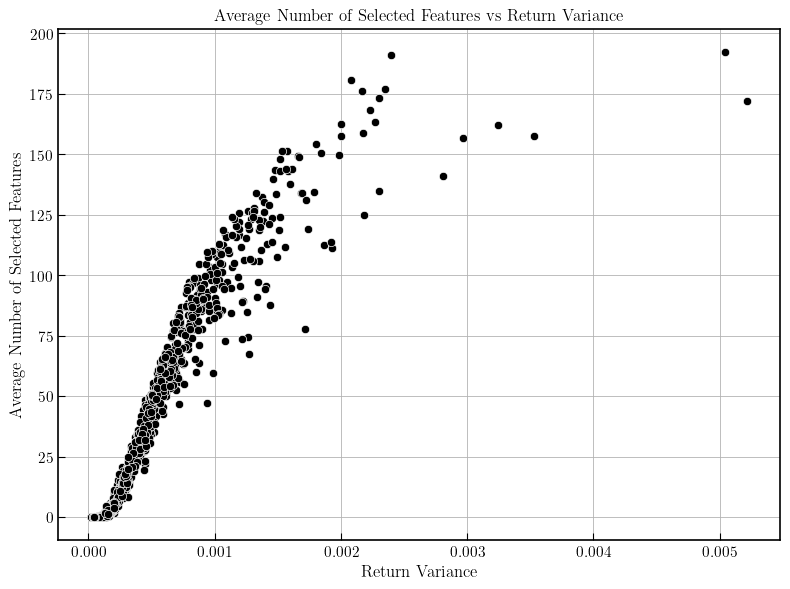

In [ ]:
#visualize a scatter plot of avg_num_selected_features vs return_variance
plt.figure(figsize=(8,6))
sns.scatterplot(data=results_df, x='return_variance', y='avg_num_selected_features')
plt.title('Average Number of Selected Features vs Return Variance')
plt.xlabel('Return Variance')
plt.ylabel('Average Number of Selected Features')
plt.tight_layout()
#save the plot
plt.savefig('/Users/tommasodifrancesco/Desktop/Lasso_paper/Manuscripts/manuscript/figures/avg_nonzero_coefficients_vs_volatility.png')
plt.show()

In [ ]:
#Now visualize the variance of each feature against the average number of times it was selected, the lags will have the same value so we sum them up
feature_selection_counts = {}
for feature in X.columns:
    total_count = 0
    for lag_number in range(1, n_lags + 1):
        col_name = f"Lasso_{feature}_lag_{lag_number}"
        if col_name in results_df.columns:
            total_count += results_df[col_name].mean()
            #take the average instead of the sum
    feature_selection_counts[feature] = total_count

In [ ]:
# now add the feature variances
feature_variances = X.var()

#create a unique dataframe for feature selection counts and variances
feature_analysis_df = pd.DataFrame({
    'selection_count': pd.Series(feature_selection_counts),
    'variance': feature_variances
})



Python(14530) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14531) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14532) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14533) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


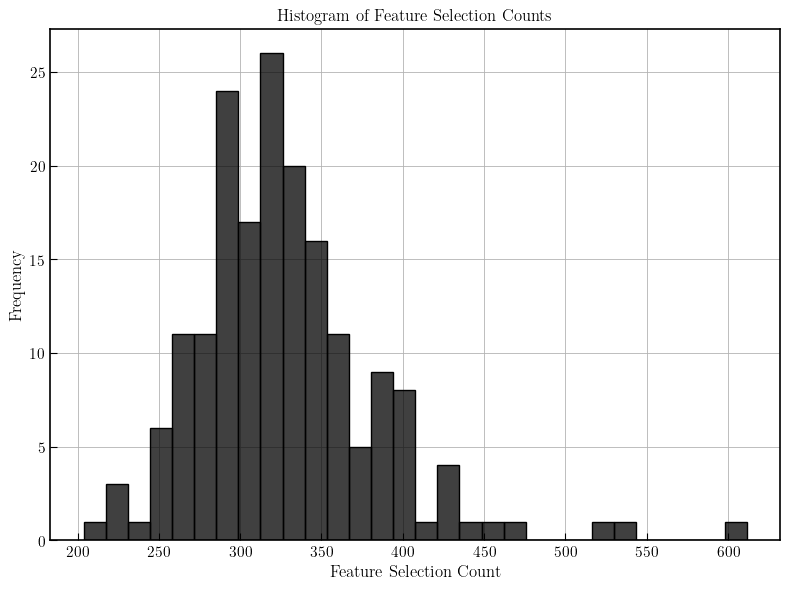

In [ ]:
#visualzie an histogram of feature selection counts
plt.figure(figsize=(8,6))
sns.histplot(feature_analysis_df['selection_count'], bins=30, kde=False)
plt.title('Histogram of Feature Selection Counts')
plt.xlabel('Feature Selection Count')
plt.ylabel('Frequency')
plt.tight_layout()
#save the plot
plt.savefig('/Users/tommasodifrancesco/Desktop/Lasso_paper/Manuscripts/manuscript/figures/histogram_feature_selection_counts.png')
plt.show()

Python(14511) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14512) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14513) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14514) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14515) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(14516) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


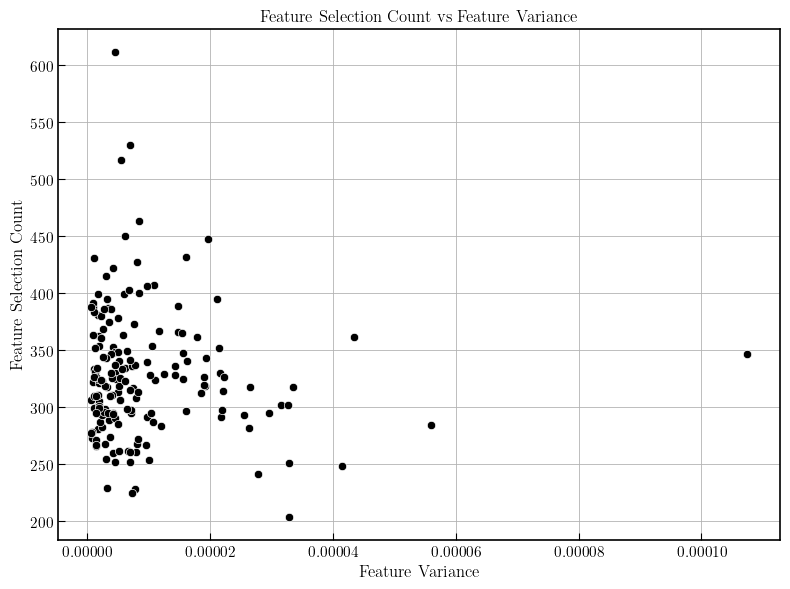

In [ ]:
#plot the selection count vs variance
plt.figure(figsize=(8,6))
sns.scatterplot(data=feature_analysis_df, x='variance', y='selection_count')
plt.title('Feature Selection Count vs Feature Variance')
plt.xlabel('Feature Variance')
plt.ylabel('Feature Selection Count')
plt.tight_layout()
#save the plot
plt.savefig('/Users/tommasodifrancesco/Desktop/Lasso_paper/Manuscripts/manuscript/figures/feature_selection_count_vs_variance.png')
plt.show()

In [ ]:
#import the csv with stock names
stock_names = pd.read_csv('../../data/stock_names.csv', index_col=0)
#remove duplicates in the # PERMNO column
stock_names = stock_names[~stock_names.index.duplicated(keep='first')]
#make sure the results_df index is made of integers
results_df.index = results_df.index.astype(int)

# add the stock names in the column COMNAM to the results_df when the idnex matched
results_df = results_df.merge(stock_names[['COMNAM']], left_index=True, right_index=True, how='left')

In [ ]:
stock_names.index, results_df.index

(Index([10026, 10028, 10032, 10044, 10065, 10066, 10104, 10107, 10113, 10138,
        ...
        93397, 93419, 93421, 93424, 93425, 93426, 93427, 93429, 93434, 93436],
       dtype='int64', name='PERMNO', length=9742),
 Index([10065, 10145, 10294, 10375, 10516, 10517, 10606, 10629, 10693, 10866,
        ...
        93101, 93104, 93117, 93122, 93123, 93150, 93153, 93174, 93175, 93178],
       dtype='int64', length=1620))

In [ ]:
#get a list of missing stock names
missing_stock_names = results_df[results_df['COMNAM'].isna()].index.tolist()
len(missing_stock_names)

382

In [ ]:
#save the missing stock names to a txt file
with open('missing_stock_names.txt', 'w') as f:
    for item in missing_stock_names:
        f.write("%s\n" % item)

In [ ]:
results_df.head()

,avg_num_selected_features,Lasso_Buffett_lag_1,Lasso_Buffett_lag_2,Lasso_Buffett_lag_3,Lasso_Buffett_lag_4,Lasso_Buffett_lag_5,Lasso_Buffett_lag_6,Lasso_Buffett_lag_7,Lasso_Buffett_lag_8,Lasso_Buffett_lag_9,...,Lasso_Negotiations_lag_10,Lasso_Negotiations_lag_11,Lasso_Negotiations_lag_12,Lasso_Negotiations_lag_13,Lasso_Negotiations_lag_14,Lasso_Negotiations_lag_15,Lasso_Negotiations_lag_16,Lasso_Negotiations_lag_17,Lasso_Negotiations_lag_18,COMNAM
10065,0.273873,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,ADAMS EXPRESS CO
10145,5.956233,3,5,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,HONEYWELL INTERNATIONAL INC
10294,49.779841,3,128,47,3,3,3,3,3,9,...,3,3,3,3,310,3,3,3,24,HAVERTY FURNITURE COS INC
10375,24.154509,3,3,3,3,5,3,3,3,3,...,3,3,3,33,3,3,3,3,3,NaN
10516,9.671088,3,18,3,3,3,3,3,19,3,...,3,3,15,3,3,3,3,3,3,ARCHER DANIELS MIDLAND CO


In [ ]:
# seaborn heatmap of the results_df
#first we reorder the rows based on the avg_num_selected_features
results_df = results_df.sort_values(by='avg_num_selected_features', ascending=False)

#we only plot cases in which at least one feature was selected

plot_df = results_df[results_df['avg_num_selected_features'] > 0]

#remove the last column COMNAM for the heatmap, but save it to show names
plot_df = plot_df.set_index(plot_df['COMNAM'])
plot_df = plot_df.drop(columns=['COMNAM'])

#remove any other columns starting with COMNAM
plot_df = plot_df.loc[:, ~plot_df.columns.str.startswith('COMNAM')]



In [ ]:
plot_df.loc['AMERICAN REALTY INVESTORS INC']

avg_num_selected_features    168.252653
Lasso_Buffett_lag_1                  68
Lasso_Buffett_lag_2                   3
Lasso_Buffett_lag_3                 101
Lasso_Buffett_lag_4                   3
                                ...    
Lasso_Negotiations_lag_14             3
Lasso_Negotiations_lag_15           216
Lasso_Negotiations_lag_16            75
Lasso_Negotiations_lag_17             8
Lasso_Negotiations_lag_18             3
Name: AMERICAN REALTY INVESTORS INC, Length: 3778, dtype: object

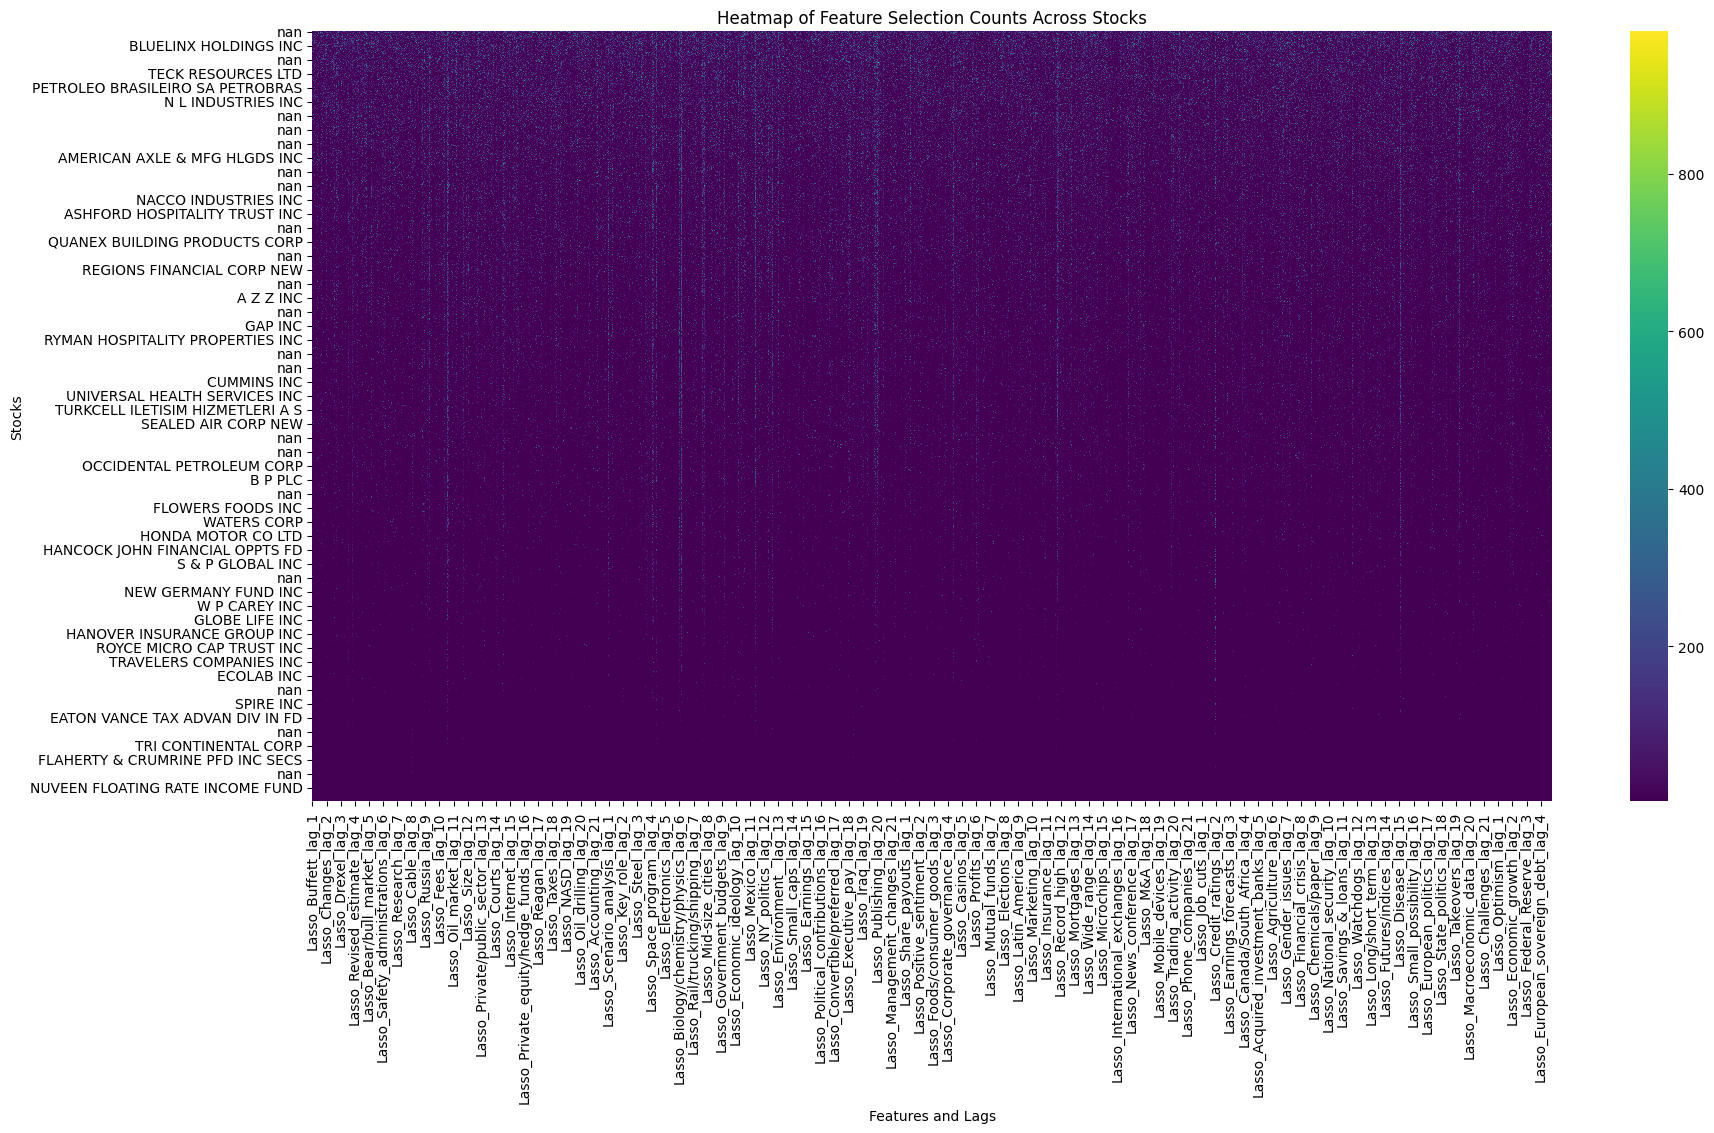

In [ ]:
plt.figure(figsize=(20, 10))
sns.heatmap(plot_df.drop(columns=['avg_num_selected_features']), cmap='viridis')
plt.title('Heatmap of Feature Selection Counts Across Stocks')
plt.xlabel('Features and Lags')
plt.ylabel('Stocks')
plt.show()

In [ ]:
variances.index, results_df.index

(Index(['10065', '10145', '10294', '10375', '10516', '10517', '10606', '10629',
        '10693', '10866',
        ...
        '93101', '93104', '93117', '93122', '93123', '93150', '93153', '93174',
        '93175', '93178'],
       dtype='object', length=1620),
 Index([91973, 92154, 89139, 83834, 92543, 90384, 91040, 49322, 76613, 77478,
        ...
        89550, 75306, 85917, 29647, 86023, 75331, 89629, 75346, 85918, 75642],
       dtype='object', length=1620))

In [ ]:
results_df.head()

,avg_num_selected_features,Lasso_Buffett_lag_1,Lasso_Buffett_lag_2,Lasso_Buffett_lag_3,Lasso_Buffett_lag_4,Lasso_Buffett_lag_5,Lasso_Buffett_lag_6,Lasso_Buffett_lag_7,Lasso_Buffett_lag_8,Lasso_Buffett_lag_9,...,Lasso_Negotiations_lag_12,Lasso_Negotiations_lag_13,Lasso_Negotiations_lag_14,Lasso_Negotiations_lag_15,Lasso_Negotiations_lag_16,Lasso_Negotiations_lag_17,Lasso_Negotiations_lag_18,COMNAM,return_variance_x,return_variance_y
91973,192.263926,46,41,396,67,194,92,28,3,50,...,8,9,3,194,3,52,3,NaN,NaN,NaN
92154,190.912467,6,94,3,4,3,7,3,145,7,...,163,228,458,463,102,90,26,NaN,NaN,NaN
89139,180.650531,31,302,84,378,289,42,141,113,16,...,22,356,5,365,3,148,3,FRONTLINE PLC,NaN,NaN
83834,176.970822,26,71,42,88,3,120,36,346,3,...,44,169,90,59,3,3,134,NaN,NaN,NaN
92543,176.15252,154,183,52,3,31,3,61,15,63,...,3,78,7,54,3,16,7,EMEREN GROUP LTD,NaN,NaN


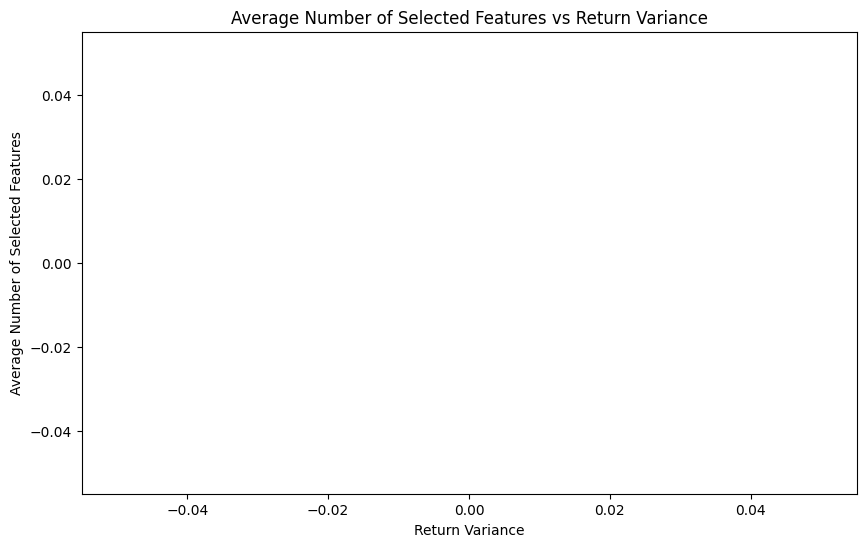

In [ ]:
#visualize a scatter plot of avg_num_selected_features vs return_variance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x='return_variance', y='avg_num_selected_features')
plt.title('Average Number of Selected Features vs Return Variance')
plt.xlabel('Return Variance')
plt.ylabel('Average Number of Selected Features')
plt.show()